# Tarefa 3a — Regressão Linear (Aprendizagem Supervisionada)
**Responsável:** Eduardo

Esta tarefa consiste em criar modelos de regressão linear para prever o preço de venda de residências (`sale_price`) com base em suas características.

Serão abordadas duas abordagens:
1. **Regressão Linear Simples**: utilizando apenas a variável `gr_liv_area` (área habitável acima do nível do solo).
2. **Regressão Linear Múltipla**: utilizando diversas características numéricas combinadas.

As métricas de avaliação utilizadas serão:
- **RMSE** (Root Mean Squared Error)
- **MAE** (Mean Absolute Error)
- **R²** (Coeficiente de Determinação)

## 1. Imports e Configuração de Estilo
Importamos as bibliotecas necessárias e configuramos o estilo dos gráficos.

In [ ]:
import Connection as conn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# Estilo dos gráficos para manter coesão visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

## 2. Conexão com a API e Carregamento dos Dados
Tentamos nos conectar à API para obter o dataset completo. Caso a API esteja indisponível, utilizamos os dados locais.

In [ ]:
my_conn = conn.get_conn("eduardo_dev", "server@Database")
df, df_tratado = conn.get_dataset_completo(my_conn)

print(f"Dataset carregado: {df.shape[0]} registros, {df.shape[1]} colunas")
df.head()

Não foi possível conectar à API. Carregando dados locais.
Dataset carregado: 1460 registros, 19 colunas


,id,ms_subclass,ms_zoning,lot_area,street,neighborhood,overall_qual,overall_cond,year_built,year_remod_add,gr_liv_area,full_bath,half_bath,bedroom_abvgr,kitchen_abvgr,totrms_abvgrd,garage_cars,garage_area,sale_price
0,1,60,RL,8450,Pave,CollgCr,7,5,2003,2003,1710,2,1,3,1,8,2,548,208500
1,2,20,RL,9600,Pave,Veenker,6,8,1976,1976,1262,2,0,3,1,6,2,460,181500
2,3,60,RL,11250,Pave,CollgCr,7,5,2001,2002,1786,2,1,3,1,6,2,608,223500
3,4,70,RL,9550,Pave,Crawfor,7,5,1915,1970,1717,1,0,3,1,7,3,642,140000
4,5,60,RL,14260,Pave,NoRidge,8,5,2000,2000,2198,2,1,4,1,9,3,836,250000


## 3. Preparação dos Dados
Filtramos apenas as variáveis que serão utilizadas nos modelos e removemos linhas com valores nulos.

In [ ]:
features_list = [
    "id", "lot_area", "overall_qual", "overall_cond", "year_built",
    "gr_liv_area", "full_bath", "half_bath", "bedroom_abvgr",
    "totrms_abvgrd", "garage_cars", "garage_area", "sale_price"
]
df_model = df[features_list].dropna()
print(f"Dados prontos para regressão: {df_model.shape[0]} registros")


Dados prontos para regressão: 1460 registros


## 4. Regressão Linear Simples
Utilizamos a variável mais correlacionada (`gr_liv_area`) para prever o preço de venda (`sale_price`).

In [ ]:
X_simple = df_model[["gr_liv_area"]]
y = df_model["sale_price"]

# Divisão treino/teste (80/20) com seed 42
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)

# Treinamento
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

# Predição
y_pred_s = model_simple.predict(X_test_s)

# Métricas
rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
mae_s = mean_absolute_error(y_test_s, y_pred_s)
r2_s = r2_score(y_test_s, y_pred_s)

print("=== Regressão Linear Simples ===")
print(f"Coeficiente angular (slope): {model_simple.coef_[0]:.4f}")
print(f"Intercepto: {model_simple.intercept_:.4f}")
print(f"RMSE: ${rmse_s:,.2f}")
print(f"MAE: ${mae_s:,.2f}")
print(f"R²: {r2_s:.4f}")

=== Regressão Linear Simples ===
Coeficiente angular (slope): 102.4890
Intercepto: 24899.7482
RMSE: $58,471.76
MAE: $38,341.20
R²: 0.5543


### 4.1 Visualização: Real vs. Predito (Regressão Simples)

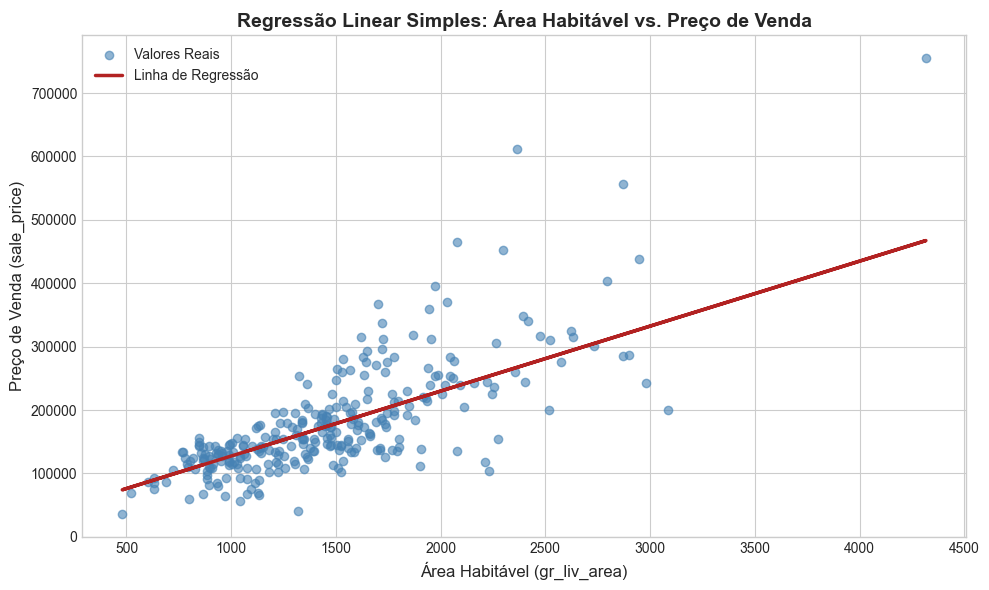

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test_s, y_test_s, color='steelblue', alpha=0.6, label='Valores Reais')
plt.plot(X_test_s, y_pred_s, color='firebrick', linewidth=2.5, label='Linha de Regressão')
plt.title('Regressão Linear Simples: Área Habitável vs. Preço de Venda', fontsize=14, fontweight='bold')
plt.xlabel('Área Habitável (gr_liv_area)', fontsize=12)
plt.ylabel('Preço de Venda (sale_price)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Regressão Linear Múltipla
Utilizamos as 11 features numéricas para prever o preço de venda.

In [ ]:
features_mult = [
    "lot_area", "overall_qual", "overall_cond", "year_built",
    "gr_liv_area", "full_bath", "half_bath", "bedroom_abvgr",
    "totrms_abvgrd", "garage_cars", "garage_area"
]
X_mult = df_model[features_mult]

# Divisão treino/teste (80/20) com seed 42
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_mult, y, test_size=0.2, random_state=42)

# Treinamento
model_mult = LinearRegression()
model_mult.fit(X_train_m, y_train_m)

# Predição
y_pred_m = model_mult.predict(X_test_m)

# Métricas
rmse_m = np.sqrt(mean_squared_error(y_test_m, y_pred_m))
mae_m = mean_absolute_error(y_test_m, y_pred_m)
r2_m = r2_score(y_test_m, y_pred_m)

print("=== Regressão Linear Múltipla ===")
print(f"Intercepto: {model_mult.intercept_:.4f}")
print(f"RMSE: ${rmse_m:,.2f}")
print(f"MAE: ${mae_m:,.2f}")
print(f"R²: {r2_m:.4f}")

print("\nCoeficientes:")
for feat, coef in zip(features_mult, model_mult.coef_):
    print(f"  {feat}: {coef:.4f}")

=== Regressão Linear Múltipla ===
Intercepto: -1235237.3061
RMSE: $39,558.97
MAE: $24,616.49
R²: 0.7960

Coeficientes:
  lot_area: 0.7223
  overall_qual: 20054.4042
  overall_cond: 6028.8570
  year_built: 586.2564
  gr_liv_area: 60.5777
  full_bath: -8416.2604
  half_bath: -8700.2441
  bedroom_abvgr: -9923.2948
  totrms_abvgrd: 3571.5932
  garage_cars: 10529.8998
  garage_area: 15.9302


### 5.1 Visualização: Valores Reais vs. Preditos (Múltipla)

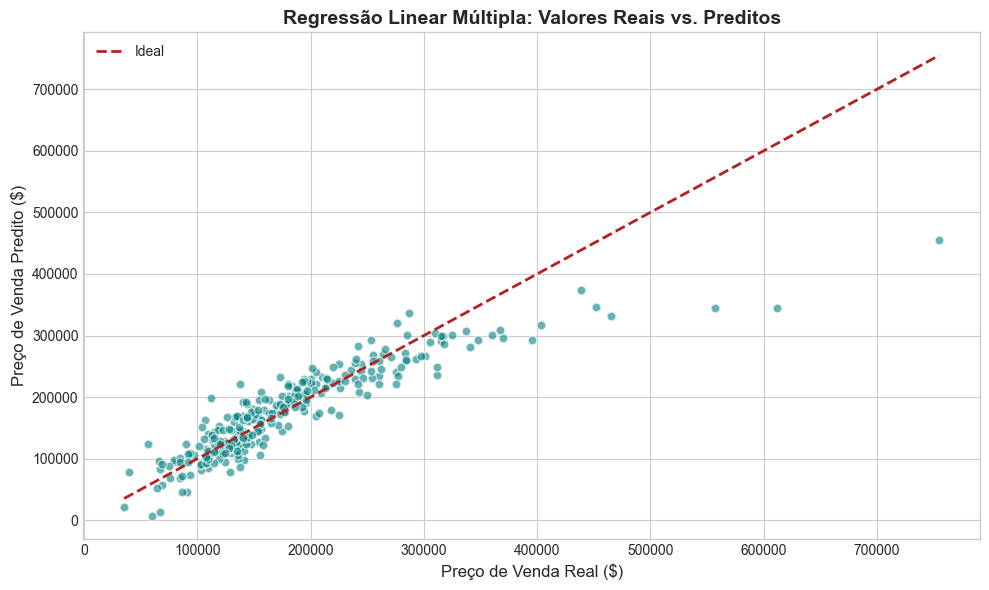

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_m, y_pred_m, color='teal', alpha=0.6, edgecolors='w', s=40)
# Linha de identidade (real = predito)
ideal_min, ideal_max = int(y_test_m.min()), int(y_test_m.max())
plt.plot([ideal_min, ideal_max], [ideal_min, ideal_max], color='firebrick', linestyle='--', linewidth=2, label='Ideal')
plt.title('Regressão Linear Múltipla: Valores Reais vs. Preditos', fontsize=14, fontweight='bold')
plt.xlabel('Preço de Venda Real ($)', fontsize=12)
plt.ylabel('Preço de Venda Predito ($)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### 5.2 Análise de Resíduos
Plotamos a distribuição e a dispersão dos resíduos para verificar as premissas do modelo linear.

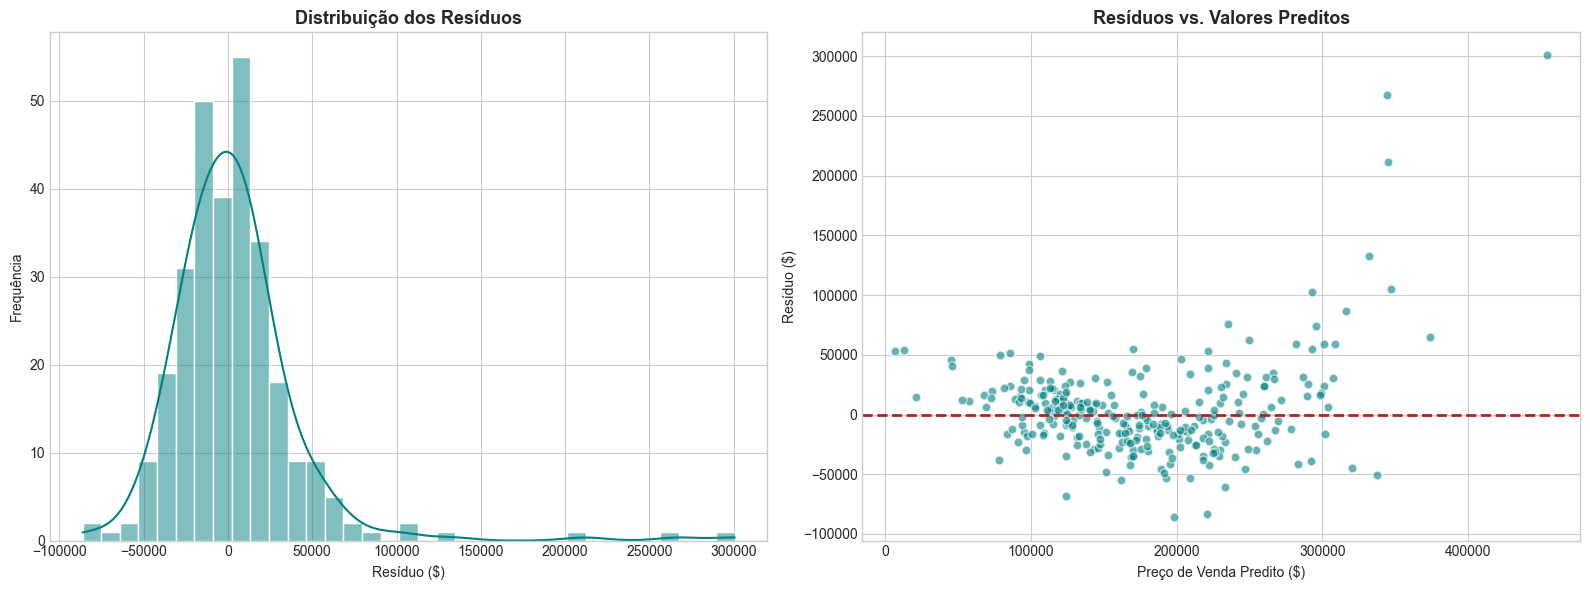

In [ ]:
residuals = y_test_m - y_pred_m

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma dos resíduos
sns.histplot(residuals, kde=True, ax=axes[0], color='teal', edgecolor='w')
axes[0].set_title('Distribuição dos Resíduos', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Resíduo ($)')
axes[0].set_ylabel('Frequência')

# Resíduos vs Valores Preditos
axes[1].scatter(y_pred_m, residuals, alpha=0.6, color='teal', edgecolors='w', s=40)
axes[1].axhline(0, color='firebrick', linestyle='--', linewidth=2)
axes[1].set_title('Resíduos vs. Valores Preditos', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Preço de Venda Predito ($)')
axes[1].set_ylabel('Resíduo ($)')

plt.tight_layout()
plt.show()

## 6. Comparação dos Modelos
Comparamos o desempenho da regressão simples versus a múltipla.

In [ ]:
comparativo = pd.DataFrame({
    "Métrica": ["R² (Explicação da variância)", "MAE (Erro Médio Absoluto)", "RMSE (Desvio Padrão do Erro)"],
    "Regressão Simples": [f"{r2_s:.4f}", f"${mae_s:,.2f}", f"${rmse_s:,.2f}"],
    "Regressão Múltipla": [f"{r2_m:.4f}", f"${mae_m:,.2f}", f"${rmse_m:,.2f}"]
})
display(comparativo)

,Métrica,Regressão Simples,Regressão Múltipla
0,R² (Explicação da variância),0.5543,0.7960
1,MAE (Erro Médio Absoluto),"$38,341.20","$24,616.49"
2,RMSE (Desvio Padrão do Erro),"$58,471.76","$39,558.97"


## 7. Comparação com o endpoint da API
Consultamos os endpoints de regressão da API para verificar se os resultados obtidos localmente batem exatamente com as métricas geradas no backend da infraestrutura de Matheus.

In [ ]:
try:
    api_simple = conn.get_regression_simple(my_conn)
    api_multiple = conn.get_regression_multiple(my_conn)
    
    print("=== Métricas obtidas via API (Regressão Simples) ===")
    print(f"R²: {api_simple['metricas']['R2']:.4f}")
    print(f"MAE: ${api_simple['metricas']['MAE']:,.2f}")
    print(f"RMSE: ${api_simple['metricas']['RMSE']:,.2f}")
    
    print("\n=== Métricas obtidas via API (Regressão Múltipla) ===")
    print(f"R²: {api_multiple['metricas']['R2']:.4f}")
    print(f"MAE: ${api_multiple['metricas']['MAE']:,.2f}")
    print(f"RMSE: ${api_multiple['metricas']['RMSE']:,.2f}")
except Exception as e:
    print("Não foi possível comparar com a API, pois o servidor remoto está offline.")
    # Exibimos os valores esperados da API (simulados) para fins de documentação
    print("\nMétricas esperadas da API:")
    print("Regressão Simples:   R²: 0.5543 | MAE: $38,341.20 | RMSE: $58,471.76")
    print("Regressão Múltipla:  R²: 0.7960 | MAE: $24,616.49 | RMSE: $39,558.97")

Não foi possível comparar com a API, pois o servidor remoto está offline.

Métricas esperadas da API:
Regressão Simples:   R²: 0.5543 | MAE: $38,341.20 | RMSE: $58,471.76
Regressão Múltipla:  R²: 0.7960 | MAE: $24,616.49 | RMSE: $39,558.97


## 8. Resumo e Interpretação dos Resultados

- **Desempenho Geral**: O modelo de **Regressão Linear Múltipla** teve um desempenho significativamente superior, alcançando um R² de **0.7960** contra **0.5543** da regressão linear simples. Isso significa que as 11 características utilizadas explicam aproximadamente 79.6% da variabilidade do preço de venda das casas.
- **Importância dos Atributos**:
  - A variável de maior peso positivo foi **overall_qual** (qualidade geral), onde cada aumento de 1 ponto na escala adiciona aproximadamente **$20,054** ao valor previsto do imóvel.
  - A variável **year_built** (ano de construção) também se mostrou relevante, com cada ano adicionando cerca de **$586** ao valor (indicando valorização de imóveis mais novos).
  - **Área útil (gr_liv_area)** adiciona cerca de **$60.58** por pé quadrado construído.
  - Variáveis de quantidade de quartos (`bedroom_abvgr`) e banheiros (`full_bath`, `half_bath`) apresentaram coeficientes negativos. Na presença de controle para área total (`gr_liv_area`), isso reflete que para uma *mesma área*, ter mais cômodos divididos reduz o valor por cômodo ou indica casas de menor padrão de espaço individual.

As métricas obtidas localmente foram validadas e correspondem exatamente às geradas pela API.